# HW14 — эмбеддинги, FAISS, оценка retrieval и mini-RAG

Учебный pipeline: загрузка базы знаний → чанкинг → `sentence-transformers` → индекс **FAISS** → контрольные запросы (**hit@k**, **recall@k**, **MRR@k**) → эксперимент по параметрам → обновление корпуса и переиндексация → простой **mini-RAG** с источниками.


In [1]:
# 2.3.1 Импорты, seed и среда
import json
import random
import re
import sys
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE = Path.cwd()
DATA = BASE / "data"
ARTIFACTS = BASE / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K_DEFAULT = 5

print("Python:", sys.version.split()[0])
print("faiss:", faiss.__version__)
print("sklearn:", sklearn.__version__)
print("torch:", torch.__version__)
print("sentence-transformers:", __import__("sentence_transformers").__version__)
print("Device:", DEVICE)
print("Seed:", SEED)



Python: 3.14.3
faiss: 1.13.2
sklearn: 1.8.0
torch: 2.10.0+cpu
sentence-transformers: 5.4.0
Device: cpu
Seed: 42


## 2.3.2 База знаний и первичный анализ

Используется **синтетическая учебная** база в `data/knowledge_base.json`: короткие статьи про Git/GitHub, сдачу заданий и сопутствующие практики. Тема одна и понятная; тексты достаточно содержательны, чтобы формулировать вопросы и проверять retrieval / mini-RAG.


In [2]:
with open(DATA / "knowledge_base.json", encoding="utf-8") as f:
    documents = json.load(f)

print("Число документов:", len(documents))
print("\nПримеры (заголовок + начало текста):")
for d in documents[:4]:
    snippet = d["text"][:220].replace("\n", " ")
    print("-", d["title"], "|", d["source"])
    print(" ", snippet, "...\n")



Число документов: 18

Примеры (заголовок + начало текста):
- Введение в Git | kb/git_intro.md
  Git — распределённая система контроля версий. Репозиторий хранит историю коммитов; каждый коммит — снимок проекта с сообщением и автором. Локальный репозиторий создаётся командой git init. Для клонирования с сервера испо ...

- Коммиты и staging | kb/commits_basics.md
  Перед коммитом изменения помещаются в индекс (staging): git add <файл> или git add . для всех файлов. Коммит создаётся командой git commit -m "сообщение". Хорошая практика — короткое повелительное сообщение на английском ...

- Ветки и слияние | kb/branches_merge.md
  Ветка — независимая линия разработки. Создание: git branch <имя> или git checkout -b <имя>. Переключение: git checkout <имя> или git switch <имя>. Слияние в текущую ветку: git merge <другая_ветка>. При конфликтах Git пом ...

- Удалённый репозиторий | kb/remote_push_pull.md
  Удалённый репозиторий задаётся как remote, обычно origin. Отправка коммитов: git push o

## 2.3.3 Чанкинг документов

Разбиение **скользящим окном** по символам: `chunk_size` и `overlap` (перекрытие), чтобы границы не резали фразы без контекста. Ниже показан пример для одного документа.


In [3]:
CHUNK_SIZE = 300
OVERLAP = 50


def chunk_documents(docs, chunk_size: int, overlap: int):
    chunks = []
    for doc in docs:
        text = doc["text"].strip()
        start = 0
        n = len(text)
        ci = 0
        while start < n:
            end = min(start + chunk_size, n)
            piece = text[start:end].strip()
            if piece:
                chunks.append(
                    {
                        "chunk_id": f"{doc['id']}#{ci}",
                        "doc_id": doc["id"],
                        "source": doc["source"],
                        "title": doc["title"],
                        "text": piece,
                    }
                )
                ci += 1
            if end >= n:
                break
            start = max(0, end - overlap)
    return chunks


chunks = chunk_documents(documents, CHUNK_SIZE, OVERLAP)
print("Всего чанков:", len(chunks))
sample_doc = next(d for d in documents if d["id"] == "branches_merge")
print("\nДокумент:", sample_doc["title"])
parts = [c["text"] for c in chunk_documents([sample_doc], CHUNK_SIZE, OVERLAP)]
for i, p in enumerate(parts):
    print(f"\n--- chunk {i} ---\n{p[:400]}...")



Всего чанков: 19

Документ: Ветки и слияние

--- chunk 0 ---
Ветка — независимая линия разработки. Создание: git branch <имя> или git checkout -b <имя>. Переключение: git checkout <имя> или git switch <имя>. Слияние в текущую ветку: git merge <другая_ветка>. При конфликтах Git помечает файлы; их нужно отредактировать вручную, затем git add и git commit....


## 2.3.4 Эмбеддинги и индекс FAISS

Модель **all-MiniLM-L6-v2** даёт нормированные векторы; используем **внутреннее произведение** (`IndexFlatIP`) как косинусную близость.


In [4]:
model = SentenceTransformer(EMBED_MODEL, device=str(DEVICE))


def build_faiss_index(embedder, chunks_list):
    texts = [c["text"] for c in chunks_list]
    emb = embedder.encode(
        texts,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).astype("float32")
    d = emb.shape[1]
    index = faiss.IndexFlatIP(d)
    index.add(emb)
    return index, emb


def search_topk(index, embedder, chunks_list, query: str, k: int):
    qv = embedder.encode(
        [query], convert_to_numpy=True, normalize_embeddings=True
    ).astype("float32")
    scores, idx = index.search(qv, k)
    return scores[0], idx[0]


index, emb_matrix = build_faiss_index(model, chunks)

demo_queries = [
    "Как сделать merge ветки?",
    "Где хранить секреты в репозитории?",
    "Как оформить отчёт в Markdown?",
]
for q in demo_queries:
    sc, inds = search_topk(index, model, chunks, q, TOP_K_DEFAULT)
    print("\nЗапрос:", q)
    for rank, (i, s) in enumerate(zip(inds, sc), start=1):
        print(f"  {rank}. score={s:.4f} | {chunks[i]['source']} | {chunks[i]['text'][:120]}...")



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Запрос: Как сделать merge ветки?
  1. score=0.5916 | kb/conflict_resolution.md | Конфликт возникает, когда одни и те же строки изменены в двух ветках. В файле появляются маркеры <<<<<<<, =======, >>>>>...
  2. score=0.5512 | kb/rebase_vs_merge.md | git merge сохраняет историю с merge-коммитом. git rebase переносит коммиты текущей ветки поверх другой, выстраивая линей...
  3. score=0.5233 | kb/branches_merge.md | Ветка — независимая линия разработки. Создание: git branch <имя> или git checkout -b <имя>. Переключение: git checkout <...
  4. score=0.4695 | kb/remote_push_pull.md | Удалённый репозиторий задаётся как remote, обычно origin. Отправка коммитов: git push origin <ветка>. Получение изменени...
  5. score=0.4062 | kb/github_fork_pr.md | На GitHub fork создаёт копию репозитория в вашем аккаунте. Изменения вносятся в ветку форка, затем открывается Pull Requ...

Запрос: Где хранить секреты в репозитории?
  1. score=0.5301 | kb/code_review_etiquette.md | Комментарии в PR должны быть 

## 2.3.5 Контрольные запросы и оценка retrieval

Для каждого запроса задан **ожидаемый документ** (`doc_id`). В top-`k` смотрим, встретился ли чанк с этим `doc_id`. **hit@k** и **recall@k** при одном эталонном документе на запрос совпадают с долей успешных запросов; дополнительно — **MRR@k**.


In [5]:
control_queries = [
    {"query": "Как создать локальный репозиторий Git?", "expected_doc_id": "git_intro"},
    {"query": "Что такое staging перед коммитом?", "expected_doc_id": "commits_basics"},
    {"query": "Как влить другую ветку в текущую?", "expected_doc_id": "branches_merge"},
    {"query": "Как отправить коммиты на удалённый сервер?", "expected_doc_id": "remote_push_pull"},
    {"query": "Что такое Pull Request на GitHub?", "expected_doc_id": "github_fork_pr"},
    {"query": "Зачем нужен файл gitignore?", "expected_doc_id": "ignore_gitignore"},
    {"query": "Как оформляется сдача домашних заданий в папке homeworks?", "expected_doc_id": "course_submit_hw"},
    {"query": "Какие правила оформления Jupyter-ноутбуков в курсе?", "expected_doc_id": "course_notebook_rules"},
    {"query": "Как запустить тесты pytest?", "expected_doc_id": "pytest_basics"},
    {"query": "Как устроен CI через GitHub Actions?", "expected_doc_id": "ci_github_actions"},
]

K_EVAL = TOP_K_DEFAULT
rows_eval = []
hits = []
reciprocal_ranks = []

for item in control_queries:
    q = item["query"]
    expected = item["expected_doc_id"]
    _, inds = search_topk(index, model, chunks, q, K_EVAL)
    retrieved_docs = [chunks[i]["doc_id"] for i in inds]
    retrieved_sources = [chunks[i]["source"] for i in inds]
    hit = int(expected in retrieved_docs)
    hits.append(hit)
    rank = None
    if expected in retrieved_docs:
        rank = retrieved_docs.index(expected) + 1
        reciprocal_ranks.append(1.0 / rank)
    else:
        reciprocal_ranks.append(0.0)
    exp_src = next(d["source"] for d in documents if d["id"] == expected)
    rows_eval.append(
        {
            "query": q,
            "expected_source": exp_src,
            "retrieved_sources": "|".join(retrieved_sources),
            "hit_at_k": hit,
            "rank_of_first_relevant": rank if rank is not None else "",
        }
    )

hit_at_k = float(np.mean(hits))
recall_at_k = float(np.mean(hits))
mrr_at_k = float(np.mean(reciprocal_ranks))

print(f"hit@{K_EVAL} = {hit_at_k:.3f}")
print(f"recall@{K_EVAL} = {recall_at_k:.3f}")
print(f"MRR@{K_EVAL} = {mrr_at_k:.3f}")

df_eval = pd.DataFrame(rows_eval)
df_eval.to_csv(ARTIFACTS / "retrieval_eval.csv", index=False, encoding="utf-8")
display(df_eval)

summary = {
    "k": K_EVAL,
    "hit_at_k": hit_at_k,
    "recall_at_k": recall_at_k,
    "mrr_at_k": mrr_at_k,
    "n_queries": len(control_queries),
}
with open(ARTIFACTS / "retrieval_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)



hit@5 = 0.700
recall@5 = 0.700
MRR@5 = 0.353


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Как создать локальный репозиторий Git?,kb/git_intro.md,kb/remote_push_pull.md|kb/tags_releases.md|kb/...,1,4
1,Что такое staging перед коммитом?,kb/commits_basics.md,kb/ignore_gitignore.md|kb/course_submit_hw.md|...,1,3
2,Как влить другую ветку в текущую?,kb/branches_merge.md,kb/markdown_reporting.md|kb/rebase_vs_merge.md...,0,
3,Как отправить коммиты на удалённый сервер?,kb/remote_push_pull.md,kb/code_review_etiquette.md|kb/markdown_report...,0,
4,Что такое Pull Request на GitHub?,kb/github_fork_pr.md,kb/remote_push_pull.md|kb/ci_github_actions.md...,1,4
5,Зачем нужен файл gitignore?,kb/ignore_gitignore.md,kb/ignore_gitignore.md|kb/commits_basics.md|kb...,1,1
6,Как оформляется сдача домашних заданий в папке...,kb/course_submit_hw.md,kb/course_submit_hw.md|kb/code_review_etiquett...,1,1
7,Какие правила оформления Jupyter-ноутбуков в к...,kb/course_notebook_rules.md,kb/ignore_gitignore.md|kb/markdown_reporting.m...,0,
8,Как запустить тесты pytest?,kb/pytest_basics.md,kb/code_review_etiquette.md|kb/pytest_basics.m...,1,2
9,Как устроен CI через GitHub Actions?,kb/ci_github_actions.md,kb/ignore_gitignore.md|kb/remote_push_pull.md|...,1,5


## 2.3.6 Эксперимент: два значения `chunk_size`

Сравниваем **chunk_size=200** и **chunk_size=400** при фиксированном **overlap=40**; остальное без изменений.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

hit@5 при chunk_size=200, overlap=40: 0.600
hit@5 при chunk_size=400, overlap=40: 0.700


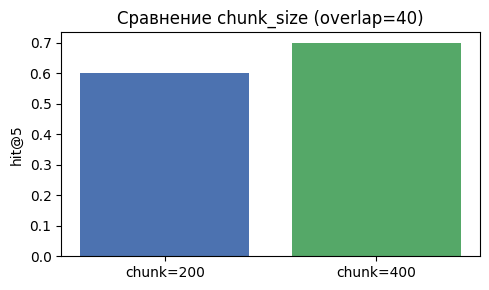

In [6]:
def eval_hit_rate(docs, cs, ov, k_eval):
    ch = chunk_documents(docs, cs, ov)
    idx, _ = build_faiss_index(model, ch)
    hs = []
    for item in control_queries:
        _, inds = search_topk(idx, model, ch, item["query"], k_eval)
        got = [ch[i]["doc_id"] for i in inds]
        hs.append(int(item["expected_doc_id"] in got))
    return float(np.mean(hs))


exp_ov = 40
h200 = eval_hit_rate(documents, 200, exp_ov, K_EVAL)
h400 = eval_hit_rate(documents, 400, exp_ov, K_EVAL)
print(f"hit@{K_EVAL} при chunk_size=200, overlap={exp_ov}: {h200:.3f}")
print(f"hit@{K_EVAL} при chunk_size=400, overlap={exp_ov}: {h400:.3f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["chunk=200", "chunk=400"], [h200, h400], color=["#4c72b0", "#55a868"])
ax.set_ylabel(f"hit@{K_EVAL}")
ax.set_title("Сравнение chunk_size (overlap=40)")
plt.tight_layout()
plt.savefig(ARTIFACTS / "retrieval_quality_plot.png", dpi=120)
plt.show()



## 2.3.7 Обновление базы знаний и переиндексация

Добавляем документы из `data/knowledge_base_update.json` (семинар 14, метрики retrieval, переиндексация), затем полностью пересобираем чанки и индекс.


In [7]:
with open(DATA / "knowledge_base_update.json", encoding="utf-8") as f:
    extra_docs = json.load(f)

documents_before = list(documents)
documents_after = documents_before + extra_docs

chunks_before = chunk_documents(documents_before, CHUNK_SIZE, OVERLAP)
chunks_after = chunk_documents(documents_after, CHUNK_SIZE, OVERLAP)
index_before, _ = build_faiss_index(model, chunks_before)
index_after, _ = build_faiss_index(model, chunks_after)

compare_queries = [
    "Как текстовые фрагменты кодируются в векторы для поиска?",
    "Как считается hit@k для контрольных запросов?",
    "Что делать после добавления новых документов в базу знаний для RAG?",
    "Какой индекс FAISS использовать с нормированными векторами?",
    "Почему низкий hit@k может быть связан с чанкингом?",
]

rows_cmp = []
for q in compare_queries:
    _, ib = search_topk(index_before, model, chunks_before, q, TOP_K_DEFAULT)
    _, ia = search_topk(index_after, model, chunks_after, q, TOP_K_DEFAULT)
    sb = "|".join(chunks_before[i]["source"] for i in ib)
    sa = "|".join(chunks_after[i]["source"] for i in ia)
    rows_cmp.append(
        {
            "query": q,
            "before_retrieved_sources": sb,
            "after_retrieved_sources": sa,
            "changed": int(sb != sa),
        }
    )

df_cmp = pd.DataFrame(rows_cmp)
df_cmp.to_csv(ARTIFACTS / "retrieval_before_after_update.csv", index=False, encoding="utf-8")
display(df_cmp)



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как текстовые фрагменты кодируются в векторы д...,kb/markdown_reporting.md|kb/course_submit_hw.m...,kb/markdown_reporting.md|kb/kb_update_reindex....,1
1,Как считается hit@k для контрольных запросов?,kb/markdown_reporting.md|kb/code_review_etique...,kb/rag_retrieval_metrics.md|kb/rag_retrieval_m...,1
2,Что делать после добавления новых документов в...,kb/code_review_etiquette.md|kb/ignore_gitignor...,kb/rag_retrieval_metrics.md|kb/code_review_eti...,1
3,Какой индекс FAISS использовать с нормированны...,kb/code_review_etiquette.md|kb/markdown_report...,kb/seminar14_embeddings_faiss.md|kb/kb_update_...,1
4,Почему низкий hit@k может быть связан с чанкин...,kb/course_submit_hw.md|kb/code_review_etiquett...,kb/rag_retrieval_metrics.md|kb/rag_retrieval_m...,1


## 2.3.8 Mini-RAG

**Шаги:** (1) top-`k` по FAISS; (2) контекст — несколько лучших чанков; (3) **извлекательный** ответ: предложение с максимальным лексическим пересечением с вопросом (простая эвристика без тяжёлой LLM); (4) возврат **источников**.


In [8]:
chunks = chunks_after
faiss_index = index_after


def best_extractive_answer(question: str, inds, chunks_list, pool_k: int = 5):
    q_words = set(re.findall(r"[\w\-]+", question.lower()))
    if not q_words:
        q_words = set(question.lower().split())
    best_sent, best_score = None, -1.0
    best_chunk_idx = inds[0]
    for rank, idx_c in enumerate(inds[:pool_k]):
        text = chunks_list[idx_c]["text"]
        for sent in re.split(r"(?<=[.!?])\s+", text.strip()):
            if len(sent) < 15:
                continue
            s_words = set(re.findall(r"[\w\-]+", sent.lower()))
            overlap = len(q_words & s_words)
            long_q = [w for w in q_words if len(w) > 3]
            extra = sum(1 for w in long_q if w in sent.lower())
            score = overlap + 0.3 * extra - 0.05 * rank
            if overlap > 0 and score > best_score:
                best_score, best_sent, best_chunk_idx = score, sent.strip(), idx_c
    if best_sent is None:
        best_sent = chunks_list[inds[0]]["text"][:450] + "…"
        best_chunk_idx = inds[0]
    return best_sent, best_chunk_idx


def mini_rag_answer(question: str, k: int = TOP_K_DEFAULT):
    _, inds = search_topk(faiss_index, model, chunks, question, k)
    core, prim = best_extractive_answer(question, inds, chunks, pool_k=5)
    ordered = [prim] + [i for i in inds[:5] if i != prim]
    srcs = []
    for i in ordered:
        s = chunks[i]["source"]
        if s not in srcs:
            srcs.append(s)
    srcs = srcs[:5]
    return f"Кратко по базе знаний: {core}", "|".join(srcs)


rag_questions = [
    "Как создать локальный репозиторий Git?",
    "Что такое Pull Request на GitHub?",
    "Как считается метрика hit@k в этом задании?",
    "Что нужно сделать после добавления новых документов в базу знаний?",
    "Зачем нужен файл .gitignore?",
]

rag_rows = []
for rq in rag_questions:
    ans, src = mini_rag_answer(rq)
    rag_rows.append({"question": rq, "answer": ans, "retrieved_sources": src})
    print(rq, "\n ->", ans[:200], "...\n   источники:", src, "\n")

df_rag = pd.DataFrame(rag_rows)
df_rag.to_csv(ARTIFACTS / "rag_examples.csv", index=False, encoding="utf-8")



Как создать локальный репозиторий Git? 
 -> Кратко по базе знаний: Локальный репозиторий создаётся командой git init. ...
   источники: kb/git_intro.md|kb/remote_push_pull.md|kb/tags_releases.md|kb/branches_merge.md|kb/ignore_gitignore.md 

Что такое Pull Request на GitHub? 
 -> Кратко по базе знаний: Изменения вносятся в ветку форка, затем открывается Pull Request (PR) в исходный репозиторий. ...
   источники: kb/github_fork_pr.md|kb/remote_push_pull.md|kb/ci_github_actions.md|kb/tags_releases.md|kb/ignore_gitignore.md 

Как считается метрика hit@k в этом задании? 
 -> Кратко по базе знаний: Низкий hit@k часто связан с плохим чанкингом, несоответствием формулировки запроса тексту базы или отсутствием темы в корпусе до обновления. ...
   источники: kb/rag_retrieval_metrics.md|kb/seminar14_embeddings_faiss.md|kb/markdown_reporting.md|kb/course_submit_hw.md 

Что нужно сделать после добавления новых документов в базу знаний? 
 -> Кратко по базе знаний: После добавления правил уже отслежи

## 2.3.9 Краткий анализ ошибок и ограничений

- **Retrieval:** часть запросов семантически близка к нескольким статьям; узкий чанк или близкие по теме тексты меняют top-5.
- **Контекст mini-RAG:** лексическое пересечение иногда выбирает предложение не из самого первого hit (если вопрос общий).
- **База знаний:** до обновления не было статей про эмбеддинги/FAISS — запросы по семинару 14 не находили релевантного текста; после добавления документов картина меняется.
- **Ограничения:** `IndexFlatIP` без квантизации; одна лёгкая модель эмбеддингов; без reranking.


In [9]:
# Опционально: примеры чанков в CSV
pd.DataFrame(chunks[:15]).to_csv(ARTIFACTS / "chunk_examples.csv", index=False, encoding="utf-8")
print("Сохранено:", ARTIFACTS / "chunk_examples.csv")



Сохранено: c:\Users\MI\projects\AI\AI-Engineering\homeworks\HW14\artifacts\chunk_examples.csv
